In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchaudio
from pathlib import Path
from IPython.display import display

GP1_DIR = Path.cwd().resolve()

DATA_GP1 = (GP1_DIR.parent / 'gp1' / 'data').resolve()

TRAIN_DIR = DATA_GP1 / 'train'
DEV_DIR = DATA_GP1 / 'dev'

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 11

print('DATA_GP1:', DATA_GP1)
print('train dir exists:', TRAIN_DIR.is_dir(), '| dev dir exists:', DEV_DIR.is_dir())

DATA_GP1: /netapp/a.gorokhova/itmo/Speech_ITMO/gp1/data
train dir exists: True | dev dir exists: True


In [2]:
REQUIRED_COLS = ['filename', 'transcription', 'spk_id', 'gender', 'ext', 'samplerate']


def find_manifest(split_dir: Path) -> Path | None:
    if not split_dir.is_dir():
        return None
    candidates = sorted(split_dir.glob('*.csv'))
    if not candidates:
        candidates = sorted(split_dir.rglob('*.csv'))
    for path in candidates:
        try:
            head = pd.read_csv(path, nrows=5)
        except Exception:
            continue
        if all(c in head.columns for c in ('filename', 'transcription')):
            return path
    return None


def audio_root_for_manifest(manifest_path: Path, split_dir: Path) -> Path:
    return split_dir

In [3]:
train_csv = find_manifest(TRAIN_DIR)
dev_csv = find_manifest(DEV_DIR)

if train_csv is None or dev_csv is None:
    raise FileNotFoundError(
        'Не найден manifest CSV. Задайте DATA_GP1 или положите данные в data/gp1/{train,dev}/'
    )

train_root = audio_root_for_manifest(train_csv, TRAIN_DIR)
dev_root = audio_root_for_manifest(dev_csv, DEV_DIR)

print('train_csv:', train_csv)
print('dev_csv: ', dev_csv)
print('train audio root:', train_root)
print('dev audio root: ', dev_root)

train_csv: /netapp/a.gorokhova/itmo/Speech_ITMO/gp1/data/train/train.csv
dev_csv:  /netapp/a.gorokhova/itmo/Speech_ITMO/gp1/data/dev/dev.csv
train audio root: /netapp/a.gorokhova/itmo/Speech_ITMO/gp1/data/train
dev audio root:  /netapp/a.gorokhova/itmo/Speech_ITMO/gp1/data/dev


In [4]:
df_train = pd.read_csv(train_csv)
df_dev = pd.read_csv(dev_csv)

for name, df in (('train', df_train), ('dev', df_dev)):
    miss = [c for c in REQUIRED_COLS if c not in df.columns]
    if miss:
        raise ValueError(f'{name}: не хватает колонок {miss}')

df_train['split'] = 'train'
df_dev['split'] = 'dev'

print('train rows:', len(df_train), '| dev rows:', len(df_dev))
display(df_train.head(3))
display(df_dev.head(3))

train rows: 12553 | dev rows: 2265


,filename,transcription,spk_id,gender,ext,samplerate,split
0,train/0007c21c23.wav,139473,spk_E,female,wav,24000,train
1,train/000bee1b1d.wav,992597,spk_B,male,wav,24000,train
2,train/001a718902.wav,500869,spk_A,female,wav,22050,train


,filename,transcription,spk_id,gender,ext,samplerate,split
0,dev/0025d6d9a9.wav,849905,spk_J,male,wav,16000,dev
1,dev/0030479d60.mp3,967653,spk_I,female,mp3,16000,dev
2,dev/003085d7a4.mp3,427524,spk_K,female,mp3,16000,dev


## Типы и пропуски

In [5]:
def summarize_frame(df: pd.DataFrame, title: str) -> None:
    print(title)
    print(df[REQUIRED_COLS].dtypes)
    print('null counts:')
    print(df[REQUIRED_COLS].isna().sum())


In [6]:
summarize_frame(df_train, '=== TRAIN ===')
summarize_frame(df_dev, '=== DEV ===')

=== TRAIN ===
filename         object
transcription     int64
spk_id           object
gender           object
ext              object
samplerate        int64
dtype: object
null counts:
filename         0
transcription    0
spk_id           0
gender           0
ext              0
samplerate       0
dtype: int64
=== DEV ===
filename         object
transcription     int64
spk_id           object
gender           object
ext              object
samplerate        int64
dtype: object
null counts:
filename         0
transcription    0
spk_id           0
gender           0
ext              0
samplerate       0
dtype: int64


## Транскрипции

In [7]:
def transcription_to_int(s: pd.Series) -> pd.Series:
    cleaned = (
        s.astype(str)
        .str.strip()
        .str.replace('_', '', regex=False)
        .str.replace(' ', '', regex=False)
    )
    bad = ~cleaned.str.fullmatch(r'\d+')
    if bad.any():
        print('Нечисловые транскрипции (первые 10):', cleaned[bad].head(10).tolist())
    return pd.to_numeric(cleaned, errors='coerce')

train: NaN после парсинга: 0
  min=14 max=999888 out of [1000,999999]: 12
dev: NaN после парсинга: 0
  min=1363 max=999669 out of [1000,999999]: 0


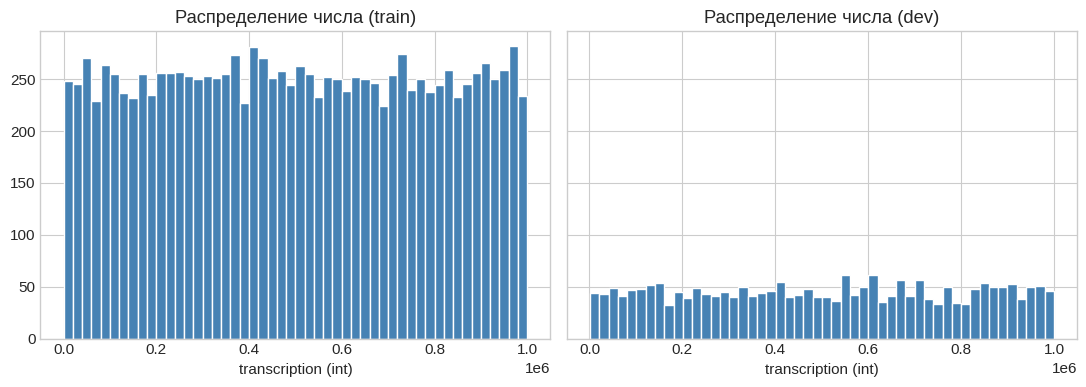

Длина строки метки (символы):
train:
 n_digits
2        3
3        9
4      116
5     1128
6    11297
Name: count, dtype: int64
dev:
 n_digits
4      23
5     199
6    2043
Name: count, dtype: int64


In [8]:
df_train['value'] = transcription_to_int(df_train['transcription'])
df_dev['value'] = transcription_to_int(df_dev['transcription'])

for name, df in (('train', df_train), ('dev', df_dev)):
    na = df['value'].isna().sum()
    print(f'{name}: NaN после парсинга: {na}')
    v = df['value'].dropna()
    print(
        f'  min={int(v.min())} max={int(v.max())} '
        f'out of [1000,999999]: {((v < 1000) | (v > 999_999)).sum()}'
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (label, df) in zip(axes, (('train', df_train), ('dev', df_dev))):
    ax.hist(df['value'].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'Распределение числа ({label})')
    ax.set_xlabel('transcription (int)')
plt.tight_layout()
plt.show()

df_train['n_digits'] = df_train['transcription'].astype(str).str.replace('_', '').str.len()
df_dev['n_digits'] = df_dev['transcription'].astype(str).str.replace('_', '').str.len()
print('Длина строки метки (символы):')
print('train:\n', df_train['n_digits'].value_counts().sort_index())
print('dev:\n', df_dev['n_digits'].value_counts().sort_index())

## Распределение - спикеры, пол, формат, sample rate

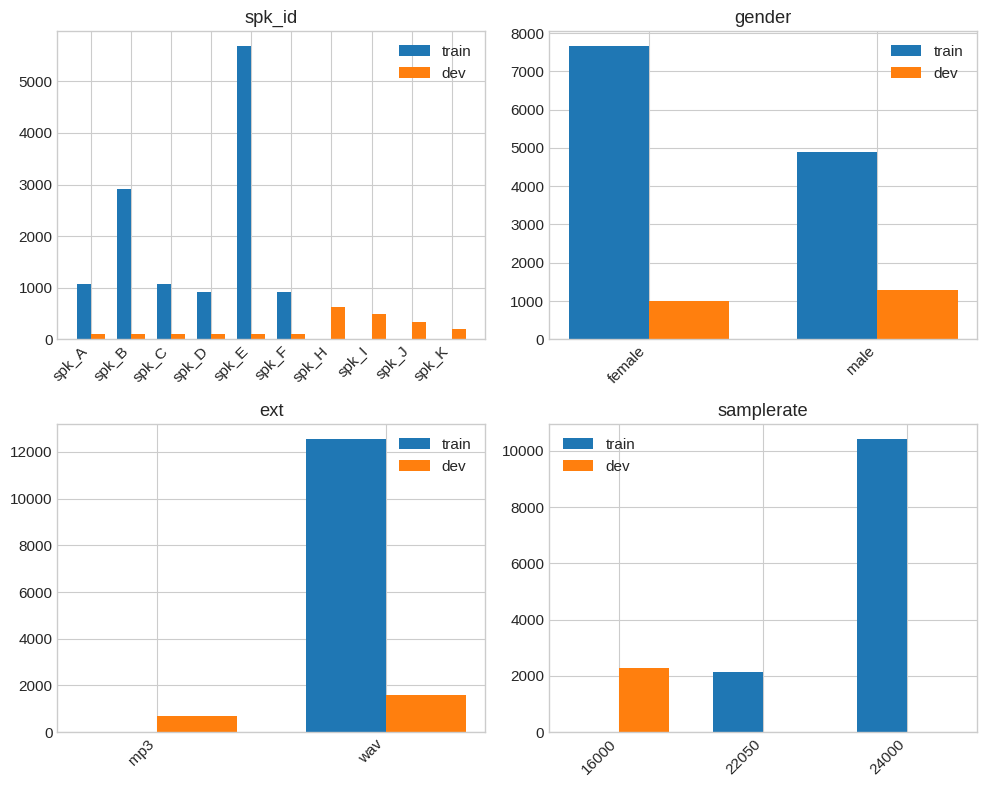

Уникальных spk_id: train 6 dev 10
Только в train: []
Только в dev:   ['spk_H', 'spk_I', 'spk_J', 'spk_K']
Пересечение:    ['spk_A', 'spk_B', 'spk_C', 'spk_D', 'spk_E', 'spk_F']


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col in zip(axes.ravel()[:4], ['spk_id', 'gender', 'ext', 'samplerate']):
    ct_tr = df_train[col].astype(str).value_counts()
    ct_de = df_dev[col].astype(str).value_counts()
    idx = sorted(set(ct_tr.index) | set(ct_de.index))
    x = np.arange(len(idx))
    w = 0.35
    ax.bar(x - w / 2, [ct_tr.get(i, 0) for i in idx], width=w, label='train')
    ax.bar(x + w / 2, [ct_de.get(i, 0) for i in idx], width=w, label='dev')
    ax.set_xticks(x)
    ax.set_xticklabels(idx, rotation=45, ha='right')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

spk_train = set(df_train['spk_id'].astype(str))
spk_dev = set(df_dev['spk_id'].astype(str))
print('Уникальных spk_id: train', len(spk_train), 'dev', len(spk_dev))
print('Только в train:', sorted(spk_train - spk_dev))
print('Только в dev:  ', sorted(spk_dev - spk_train))
print('Пересечение:   ', sorted(spk_train & spk_dev))

## Длительности аудио

In [10]:
USE_FULL_SPLIT = False
SAMPLE_SIZE = 2500

_duration_rng = np.random.default_rng(0)


def sample_indices(n: int, size: int) -> np.ndarray:
    size = min(size, n)
    return _duration_rng.choice(np.arange(n), size=size, replace=False)


def compute_durations(
    df: pd.DataFrame,
    root: Path,
    *,
    full: bool,
    sample_size: int,
) -> pd.DataFrame:
    n = len(df)
    if full:
        idxs = np.arange(n)
    else:
        idxs = sample_indices(n, min(sample_size, n))
    rows = []
    for i in idxs:
        row = df.iloc[int(i)]
        path = root / str(row['filename'])
        if not path.is_file():
            continue
        try:
            info = torchaudio.info(str(path))
            dur = info.num_frames / float(info.sample_rate)
        except Exception:
            continue
        rows.append(
            {
                'duration_s': dur,
                'sample_rate': int(info.sample_rate),
                'spk_id': row['spk_id'],
                'split': row['split'],
            }
        )
    return pd.DataFrame(rows)

/ssd/a.gorokhova/usr/anaconda3/envs/audio_itmo/lib/python3.11/site-packages/torchaudio/_backend/soundfile_backend.py:71: UserWarning: The MPEG_LAYER_III subtype is unknown to TorchAudio. As a result, the bits_per_sample attribute will be set to 0. If you are seeing this warning, please report by opening an issue on github (after checking for existing/closed ones). You may otherwise ignore this warning.
  warnings.warn(


Сэмплов с измеренной длительностью: 4765


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,2265.0,3.374891,2.169037,1.400000,2.880000,3.279875,3.720000,101.06400
train,2500.0,3.067182,0.492220,1.070375,2.777469,3.037324,3.306792,5.11551


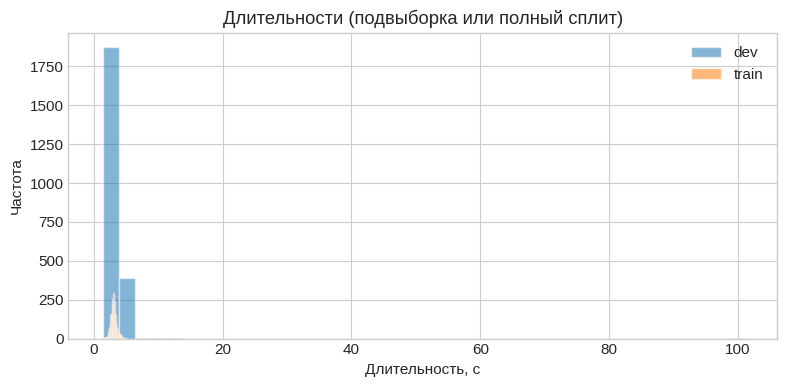

In [11]:
dur_train = compute_durations(df_train, train_root, full=USE_FULL_SPLIT, sample_size=SAMPLE_SIZE)
dur_dev = compute_durations(df_dev, dev_root, full=USE_FULL_SPLIT, sample_size=SAMPLE_SIZE)
dur_all = pd.concat([dur_train, dur_dev], ignore_index=True)

print('Сэмплов с измеренной длительностью:', len(dur_all))
display(dur_all.groupby('split')['duration_s'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
for label, sub in dur_all.groupby('split'):
    ax.hist(sub['duration_s'], bins=40, alpha=0.55, label=label, edgecolor='white')
ax.set_xlabel('Длительность, с')
ax.set_ylabel('Частота')
ax.legend()
ax.set_title('Длительности (подвыборка или полный сплит)')
plt.tight_layout()
plt.show()

## Визуализации

In [12]:
N_EXAMPLES = 6
TARGET_SR = 16_000
PICK_TRANSCRIPTIONS: list[str] | None = None  # например: ['1005', '809017', '250000']

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=400,
    hop_length=160,
    n_mels=80,
    f_min=0.0,
    f_max=TARGET_SR / 2,
    power=2.0,
)
to_db = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80)


def load_mono_resampled(path: Path, target_sr: int):
    wav, sr = torchaudio.load(str(path))
    if wav.dim() == 2 and wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    return wav, target_sr


def pick_sample_rows(df: pd.DataFrame, n: int, pick_list: list[str] | None):
    if pick_list:
        rows = []
        for t in pick_list:
            sub = df[df['transcription'].astype(str) == str(t)]
            if len(sub) == 0:
                print(f'Нет строк с transcription={t!r} в этом фрейме')
                continue
            rows.append(sub.iloc[0])
        if not rows:
            raise ValueError('PICK_TRANSCRIPTIONS: ни одна метка не найдена')
        return pd.DataFrame(rows).reset_index(drop=True)
    u = df.drop_duplicates(subset=['transcription'])
    n = min(n, len(u))
    return u.sample(n=n, random_state=42).reset_index(drop=True)


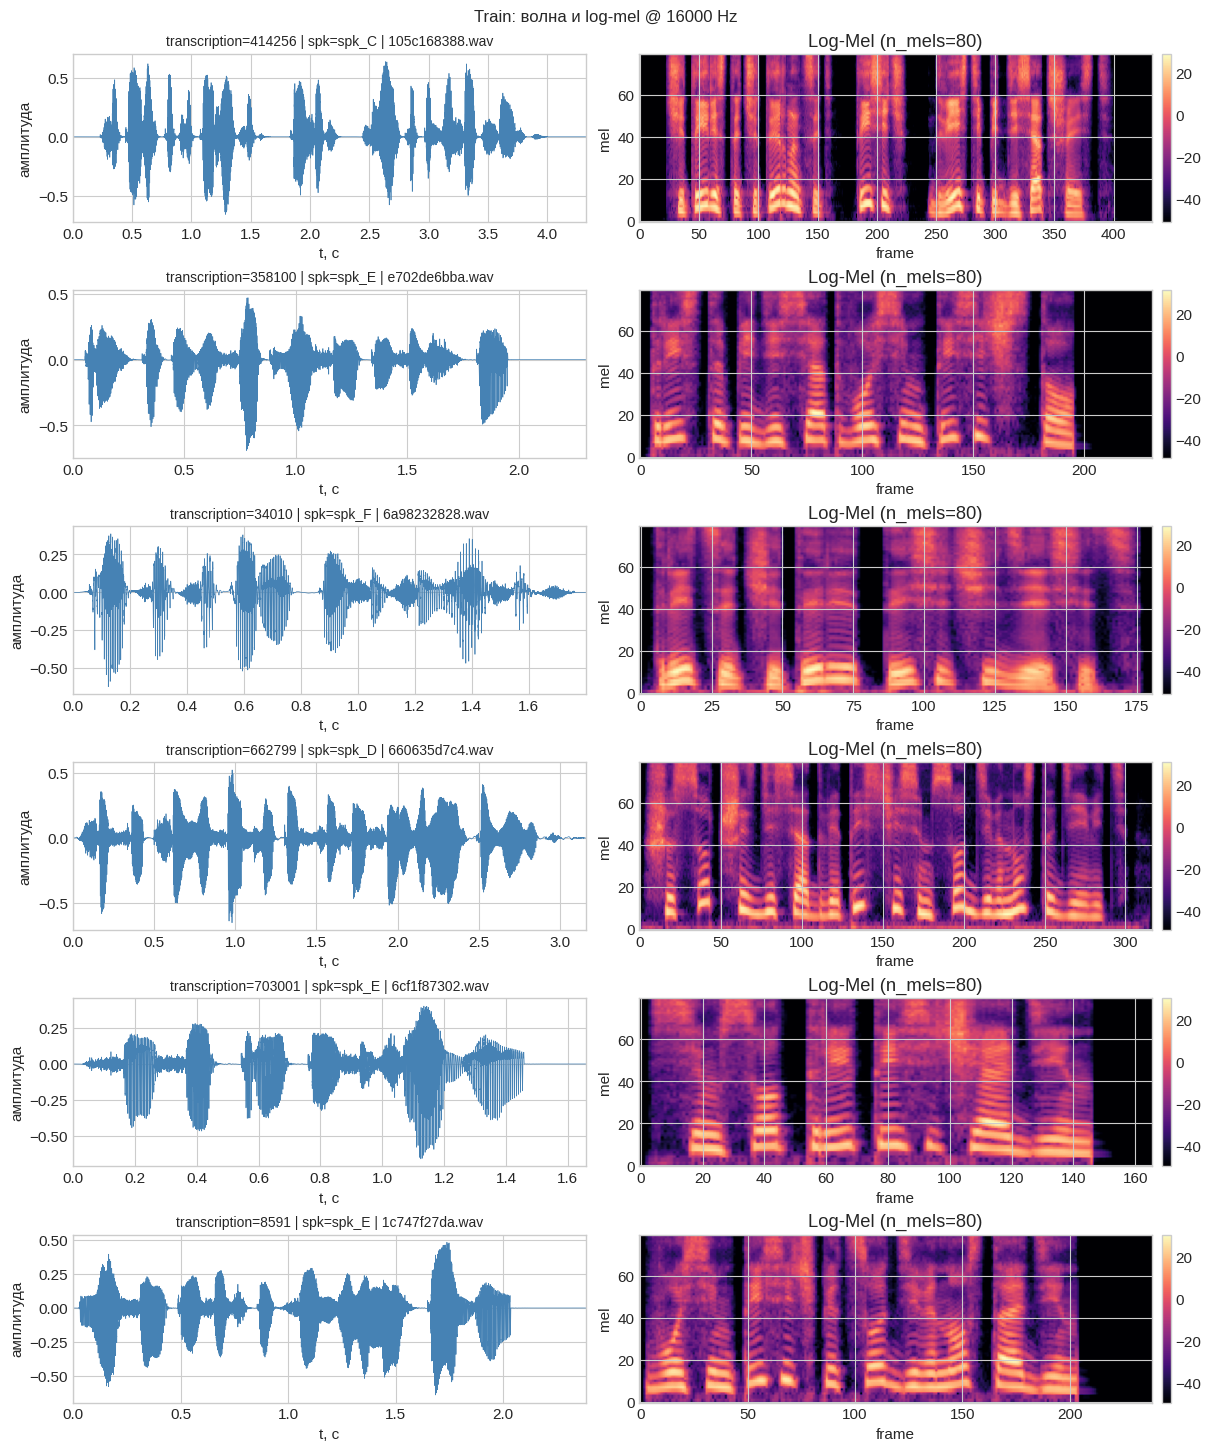

In [13]:
sample_rows = pick_sample_rows(df_train, N_EXAMPLES, PICK_TRANSCRIPTIONS)
n = len(sample_rows)
fig, axes = plt.subplots(n, 2, figsize=(12, 2.4 * n), constrained_layout=True)
if n == 1:
    axes = np.expand_dims(np.array(axes), axis=0)

for i in range(n):
    row = sample_rows.iloc[i]
    p = train_root / str(row['filename'])
    ax_w, ax_m = axes[i, 0], axes[i, 1]
    if not p.is_file():
        ax_w.set_title(f'Файл не найден: {p}')
        ax_m.axis('off')
        ax_w.axis('off')
        continue
    wav, sr = load_mono_resampled(p, TARGET_SR)
    t = np.arange(wav.shape[-1]) / sr
    ax_w.plot(t, wav.squeeze().numpy(), color='steelblue', linewidth=0.5)
    ttl = f"transcription={row['transcription']} | spk={row['spk_id']} | {p.name}"
    ax_w.set_title(ttl, fontsize=10)
    ax_w.set_xlabel('t, c')
    ax_w.set_ylabel('амплитуда')
    ax_w.set_xlim(0, t[-1])

    with torch.inference_mode():
        mel = to_db(mel_transform(wav))
    mel_np = mel.squeeze().numpy()
    im = ax_m.imshow(mel_np, aspect='auto', origin='lower', cmap='magma')
    ax_m.set_title('Log-Mel (n_mels=80)')
    ax_m.set_xlabel('frame')
    ax_m.set_ylabel('mel')
    plt.colorbar(im, ax=ax_m, fraction=0.046, pad=0.02)

fig.suptitle(f'Train: волна и log-mel @ {TARGET_SR} Hz', fontsize=12)
plt.show()

## Пример

In [14]:
from IPython.display import Audio, display
import torchaudio
row = df_train.iloc[1000]
p = train_root / str(row['filename'])
wav, sr = torchaudio.load(str(p))
if wav.shape[0] > 1:
    wav = wav.mean(dim=0, keepdim=True)
display(Audio(wav.numpy(), rate=sr))
print('transcription:', row['transcription'], 'spk_id:', row['spk_id'])

transcription: 80684 spk_id: spk_B
